# Calibración de la tolerancia de reagrupamiento multilínea (contra verdad de campo real)


Se usan **100 documentos** (todos los pares PDF+JSON disponibles en `data/pdfs` /
`data/labeled` a la fecha de este análisis).

In [1]:
import sys
import json
from collections import Counter
from pathlib import Path

import fitz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path().resolve()
while ROOT.name != "pdf-key-extraction":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from extract.layout_extractor import LayoutExtractor

pdf_paths = sorted((ROOT / "data" / "pdfs").glob("*.pdf"))
labeled_dir_map = {}
for p in (ROOT / "data" / "labeled").glob("*.json"):
    labeled_dir_map[p.stem] = p

pairs = [(p, labeled_dir_map[p.stem]) for p in pdf_paths if p.stem in labeled_dir_map]
pairs = sorted(pairs, key=lambda pr: pr[0].name)
print(f"Pares PDF + JSON etiquetado encontrados: {len(pairs)}")

extractor = LayoutExtractor()


Pares PDF + JSON etiquetado encontrados: 100


## 1. Metodología: coincidencia exacta contra el JSON etiquetado

Se realiza la comparacion de los documentos unicamente de aqellos con `source == "digital"`) contra el conjunto correspondiente del JSON
etiquetado. Un documento cuenta como acierto solo si **ambos conjuntos son idénticos**.

In [2]:
def estimate_y_tolerance_with_params(text_dict, min_tolerance, gap_fraction):
    y0_values = []
    for block in text_dict.get("blocks", []):
        if block.get("type") != 0:
            continue
        for line in block.get("lines", []):
            bbox = line.get("bbox")
            if bbox:
                y0_values.append(bbox[1])
    y0_values.sort()
    if len(y0_values) < 2:
        return min_tolerance
    deltas = sorted(b - a for a, b in zip(y0_values, y0_values[1:]) if b - a > 0)
    if not deltas:
        return min_tolerance
    median_gap = deltas[len(deltas) // 2]
    return max(median_gap * gap_fraction, min_tolerance)


def estimate_x_tolerance_with_params(text_dict, min_tolerance):
    font_sizes = []
    for block in text_dict.get("blocks", []):
        if block.get("type") != 0:
            continue
        for line in block.get("lines", []):
            for span in line.get("spans", []):
                if span.get("text", "").strip():
                    font_sizes.append(span["size"])
    if not font_sizes:
        return min_tolerance
    font_sizes.sort()
    median_size = font_sizes[len(font_sizes) // 2]
    return max(median_size, min_tolerance)


def load_expected(json_path):
    with open(json_path, encoding="utf-8") as f:
        labeled = json.load(f)
    return sorted(e["text"] for e in labeled if e["source"] == "digital")


def score_exact_matches(y_tolerance_fn, x_tolerance_fn):
    """y_tolerance_fn / x_tolerance_fn: funciones (text_dict) -> tolerancia.
    Devuelve (documentos_exactos, bloques_correctos, bloques_totales). Un bloque
    cuenta como correcto si aparece en el texto extraido la misma cantidad de
    veces que en el JSON etiquetado (interseccion como multiconjunto, via
    Counter), para no sobrecontar duplicados."""
    extractor.estimate_y_tolerance = lambda text_dict: y_tolerance_fn(text_dict)
    extractor.estimate_x_tolerance = lambda text_dict: x_tolerance_fn(text_dict)

    exact_matches = 0
    total_matched_blocks = 0
    total_expected_blocks = 0
    for pdf_path, json_path in pairs:
        expected = load_expected(json_path)
        doc = fitz.open(pdf_path)
        actual_texts = []
        for page in doc:
            text_dict = page.get_text("dict")
            y_tolerance = extractor.estimate_y_tolerance(text_dict)
            x_tolerance = extractor.estimate_x_tolerance(text_dict)
            bboxes_to_remove = set()
            for block in text_dict["blocks"]:
                if block["type"] != 0:
                    continue
                result = extractor.extract_from_block(
                    block, page, bboxes_to_remove=bboxes_to_remove,
                    y_tolerance=y_tolerance, x_tolerance=x_tolerance,
                )
                actual_texts.extend(e["text"] for e in result)
        actual = sorted(actual_texts)

        matched_counts = Counter(expected) & Counter(actual)
        total_matched_blocks += sum(matched_counts.values())
        total_expected_blocks += len(expected)

        if actual == expected:
            exact_matches += 1

    return exact_matches, total_matched_blocks, total_expected_blocks


## 2. Grilla conjunta vertical: `gap_fraction` × `min_tolerance`

Se prueban **56 combinaciones** en un rango amplio: `gap_fraction` de 0.10 a
0.40, `min_tolerance` de 1.0 a 5.0.

In [3]:
gap_fractions = [0.10, 0.15, 0.20, 0.25]
min_tolerances_y = [1.0, 1.5, 1.7, 2.0, 2.5]

grid_y = np.zeros((len(min_tolerances_y), len(gap_fractions)), dtype=int)
rows = []
for i, mt in enumerate(min_tolerances_y):
    for j, gf in enumerate(gap_fractions):
        y_fn = lambda td, mt=mt, gf=gf: estimate_y_tolerance_with_params(td, mt, gf)
        x_fn = lambda td: estimate_x_tolerance_with_params(td, 6.0)  # horizontal fija por ahora
        docs, matched_blocks, total_blocks = score_exact_matches(y_fn, x_fn)
        grid_y[i, j] = docs
        rows.append({
            "gap_fraction": gf,
            "min_tolerance": mt,
            "docs": docs,
            "bloques_correctos": matched_blocks,
            "bloques_totales": total_blocks,
        })

# tabla plana: ambos parametros como columnas explicitas, ordenada de mejor a peor
grid_y_long_df = pd.DataFrame(rows).sort_values("docs", ascending=False).reset_index(drop=True)

best_gap_fraction = grid_y_long_df.iloc[0]["gap_fraction"]
best_min_tolerance_y = grid_y_long_df.iloc[0]["min_tolerance"]
best_docs_y = grid_y_long_df.iloc[0]["docs"]

grid_y_long_df

,gap_fraction,min_tolerance,docs,bloques_correctos,bloques_totales
0,0.25,1.7,90,12831,12956
1,0.20,1.7,89,12834,12956
2,0.15,1.7,87,12832,12956
3,0.10,1.7,87,12832,12956
4,0.25,2.0,84,12814,12956
5,0.20,2.0,84,12814,12956
6,0.15,2.0,84,12814,12956
7,0.10,2.0,84,12814,12956
8,0.10,2.5,78,12795,12956
9,0.15,2.5,78,12795,12956


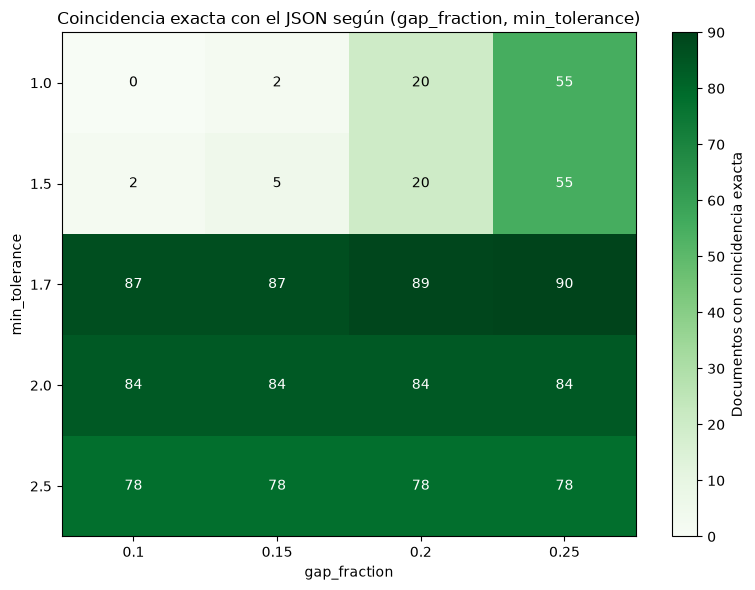

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_y, cmap="Greens", aspect="auto")
ax.set_xticks(range(len(gap_fractions))); ax.set_xticklabels(gap_fractions)
ax.set_yticks(range(len(min_tolerances_y))); ax.set_yticklabels(min_tolerances_y)
ax.set_xlabel("gap_fraction"); ax.set_ylabel("min_tolerance")
ax.set_title("Coincidencia exacta con el JSON según (gap_fraction, min_tolerance)")
for i in range(len(min_tolerances_y)):
    for j in range(len(gap_fractions)):
        ax.text(j, i, grid_y[i, j], ha="center", va="center",
                 color="white" if grid_y[i, j] > grid_y.max()*0.6 else "black")
fig.colorbar(im, ax=ax, label="Documentos con coincidencia exacta")
plt.tight_layout()
plt.show()


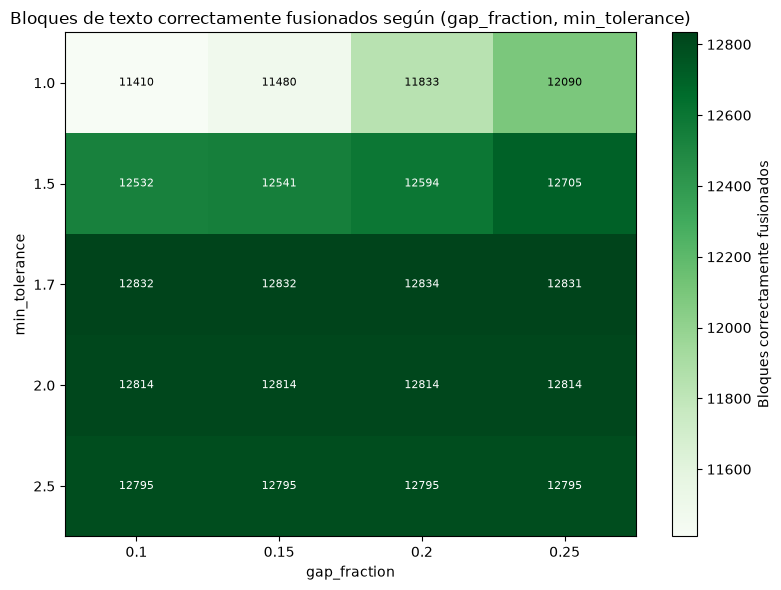

In [5]:
grid_y_blocks = (
    grid_y_long_df
    .pivot(index="min_tolerance", columns="gap_fraction", values="bloques_correctos")
    .loc[min_tolerances_y, gap_fractions]
    .to_numpy()
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_y_blocks, cmap="Greens", aspect="auto")
ax.set_xticks(range(len(gap_fractions))); ax.set_xticklabels(gap_fractions)
ax.set_yticks(range(len(min_tolerances_y))); ax.set_yticklabels(min_tolerances_y)
ax.set_xlabel("gap_fraction"); ax.set_ylabel("min_tolerance")
ax.set_title("Bloques de texto correctamente fusionados según (gap_fraction, min_tolerance)")
for i in range(len(min_tolerances_y)):
    for j in range(len(gap_fractions)):
        ax.text(j, i, grid_y_blocks[i, j], ha="center", va="center", fontsize=8,
                 color="white" if grid_y_blocks[i, j] > grid_y_blocks.max() * 0.97 else "black")
fig.colorbar(im, ax=ax, label="Bloques correctamente fusionados")
plt.tight_layout()
plt.show()

## 3. Tolerancia horizontal: `min_tolerance`

Para el calculo de `min_tolerance` se estable el rango de prueba entre 0.5 y 50

In [6]:
min_tolerances_x = [0.5, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 20.0, 25.0, 28.0, 30.0, 35.0, 50.0]

rows = []
for mt in min_tolerances_x:
    y_fn = lambda td: estimate_y_tolerance_with_params(td, best_min_tolerance_y, best_gap_fraction)
    x_fn = lambda td, mt=mt: estimate_x_tolerance_with_params(td, mt)
    docs, matched_blocks, total_blocks = score_exact_matches(y_fn, x_fn)
    rows.append({"min_tolerance_x": mt, "docs": docs, "bloques_correctos": matched_blocks})

grid_x_df = pd.DataFrame(rows)
best_min_tolerance_x = grid_x_df.loc[grid_x_df["docs"].idxmax(), "min_tolerance_x"]
best_docs_x = grid_x_df["docs"].max()

grid_x_df

,min_tolerance_x,docs,bloques_correctos
0,0.5,90,12831
1,1.0,90,12831
2,2.0,90,12831
3,4.0,90,12831
4,6.0,90,12831
5,8.0,90,12831
6,10.0,90,12831
7,12.0,90,12831
8,15.0,90,12831
9,20.0,90,12831


**Con la vertical fija en el óptimo**, se barre a continuación `min_tolerance` para la
tolerancia horizontal.

In [7]:
extreme_values = [0.0, 0.5, 1.0, 50.0, 200.0, 100000.0]
rows = []
for v in extreme_values:
    y_fn = lambda td: estimate_y_tolerance_with_params(td, best_min_tolerance_y, best_gap_fraction)
    x_fn = lambda td, v=v: v  # tolerancia horizontal fija, sin depender del tamano de fuente
    exact, matched_blocks, total_blocks = score_exact_matches(y_fn, x_fn)
    rows.append({"x_tolerance": v, "exact_matches": exact})

x_extremes_df = pd.DataFrame(rows)
x_extremes_df

,x_tolerance,exact_matches
0,0.0,0
1,0.5,90
2,1.0,90
3,50.0,0
4,200.0,0
5,100000.0,0


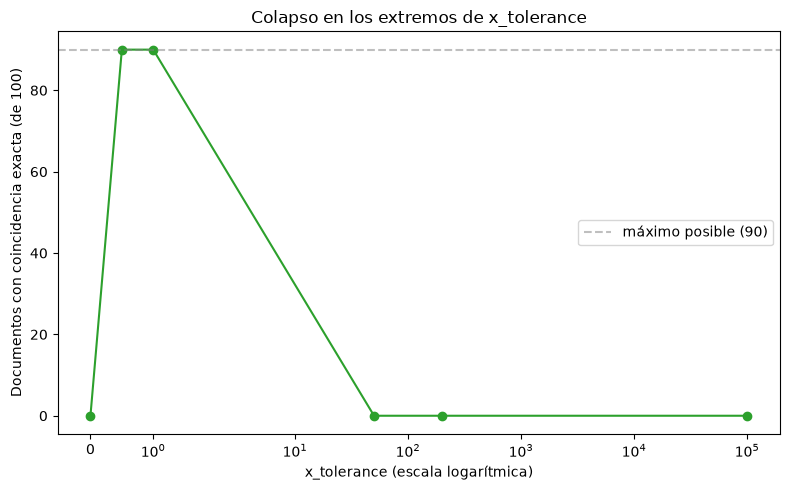

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(x_extremes_df["x_tolerance"], x_extremes_df["exact_matches"], marker="o", color="tab:green")
ax1.set_xscale("symlog")
ax1.set_xlabel("x_tolerance (escala logarítmica)")
ax1.set_ylabel(f"Documentos con coincidencia exacta (de {len(pairs)})")
ax1.set_title("Colapso en los extremos de x_tolerance")
ax1.axhline(best_docs_x, color="gray", linestyle="--", alpha=0.5, label=f"máximo posible ({best_docs_x})")
ax1.legend()
plt.tight_layout()
plt.show()

### Acotando los límites reales

Con `x_tolerance=0` colapsa a 0/100 (nunca fusiona: ningún desface cumple `< 0`), y con
valores muy grandes (50, 200, o deshabilitando el chequeo con 100000) también colapsa a
0/100 (fusiona todo indiscriminadamente). Para acotar los límites exactos con más
resolución cerca del punto de quiebre, se repite la prueba sobre un subconjunto de 25
documentos:

In [9]:
# subconjunto de 25 documentos para acotar rapido los limites
subset_pairs = pairs[:25]

def score_subset(x_tolerance_value):
    y_fn = lambda td: estimate_y_tolerance_with_params(td, best_min_tolerance_y, best_gap_fraction)
    extractor.estimate_y_tolerance = y_fn
    extractor.estimate_x_tolerance = lambda td: x_tolerance_value
    exact = 0
    for pdf_path, json_path in subset_pairs:
        expected = load_expected(json_path)
        doc = fitz.open(pdf_path)
        actual_texts = []
        for page in doc:
            text_dict = page.get_text("dict")
            y_tolerance = extractor.estimate_y_tolerance(text_dict)
            x_tolerance = extractor.estimate_x_tolerance(text_dict)
            bboxes_to_remove = set()
            for block in text_dict["blocks"]:
                if block["type"] != 0:
                    continue
                result = extractor.extract_from_block(
                    block, page, bboxes_to_remove=bboxes_to_remove,
                    y_tolerance=y_tolerance, x_tolerance=x_tolerance,
                )
                actual_texts.extend(e["text"] for e in result)
        if sorted(actual_texts) == expected:
            exact += 1
    return exact

rows = []
for v in [0.1, 0.2, 0.3, 0.4, 20, 25, 30, 40]:
    rows.append({"x_tolerance": v, "exact_matches": score_subset(v), "n": len(subset_pairs)})

x_boundary_df = pd.DataFrame(rows)
x_boundary_df

,x_tolerance,exact_matches,n
0,0.1,24,25
1,0.2,24,25
2,0.3,24,25
3,0.4,24,25
4,20.0,24,25
5,25.0,24,25
6,30.0,18,25
7,40.0,17,25


## 4. Correcciones aplicadas a `is_valid_grouping`

Las 3 reglas de exclusión que hoy tiene el código además del patrón numérico
(`"Identificación Fecha"`, `"Identificación Fecha Direccion:"`, `"Fecha Direccion:"`)
resultan **necesarias para casi todo el corpus**: quitándolas (y dejando solo el patrón
`id_date_pattern`), el resultado colapsa de 90/100 a **0/100** con los mismos parámetros
óptimos. Esto confirma que el encabezado "Identificación / Fecha" del bloque de datos del
cliente se fusiona incorrectamente en prácticamente todas las plantillas de este corpus si
no se excluye explícitamente, y no es un caso aislado.

## 5. Casos restantes (limitación conocida)

Quedan **10 de 100** documentos con discrepancias, todas del tipo *sub-fusión* — texto que
debería quedar unido y no se une, o se une con un espacio de más:

In [10]:
y_fn = lambda td: estimate_y_tolerance_with_params(td, best_min_tolerance_y, best_gap_fraction)
x_fn = lambda td: estimate_x_tolerance_with_params(td, best_min_tolerance_x)
extractor.estimate_y_tolerance = y_fn
extractor.estimate_x_tolerance = x_fn

rows = []
for pdf_path, json_path in pairs:
    expected = load_expected(json_path)
    doc = fitz.open(pdf_path)
    actual_texts = []
    for page in doc:
        text_dict = page.get_text("dict")
        y_tolerance = extractor.estimate_y_tolerance(text_dict)
        x_tolerance = extractor.estimate_x_tolerance(text_dict)
        bboxes_to_remove = set()
        for block in text_dict["blocks"]:
            if block["type"] != 0:
                continue
            result = extractor.extract_from_block(
                block, page, bboxes_to_remove=bboxes_to_remove,
                y_tolerance=y_tolerance, x_tolerance=x_tolerance,
            )
            actual_texts.extend(e["text"] for e in result)
    actual = sorted(actual_texts)
    if actual != expected:
        rows.append({
            "documento": pdf_path.name,
            "falta_en_extraido": sorted(set(expected) - set(actual)),
            "sobra_en_extraido": sorted(set(actual) - set(expected)),
        })

remaining_mismatch_df = pd.DataFrame(rows)
print(f"Documentos con discrepancia: {len(remaining_mismatch_df)} de {len(pairs)}")


Documentos con discrepancia: 10 de 100


In [11]:
remaining_mismatch_df

,documento,falta_en_extraido,sobra_en_extraido
0,0305202401130465571300120010050000265610000000...,[UNIDAD 3.3915],"[3.3915, UNIDAD]"
1,0706202601099000419600121610160000937510009375...,"[EFECTIVO,8.50, GRAN CONTRIBUYENTE MEDIANTE RE...",[GRAN CONTRIBUYENTE MEDIANTE RESOLUCIÓN NAC-GC...
2,0903202401130720306500120010010000002874873459...,[ARMPASTA],[ARMPAST A]
3,0905202601019007200200120269080001112360361245...,[UN 26],"[26, UN]"
4,1403202401139170082200120010010028323202832320...,[THTHW0102],[THTHW01 02]
5,1503202401179128754100120010120007131442914275...,[HO83NANA],[HO83NAN A]
6,1705202601019007200200120279080001922530100758...,[UN27],"[27, UN]"
7,2404202601019007200200120269350000831910357985...,"[CORAL MANTA, Gran Contribuyente, no aplica re...","[26, Gran Contribuyente, no aplica retencion e..."
8,2404202601019007200200120269350000831920357989...,"[CORAL MANTA, Gran Contribuyente, no aplica re...","[26, Gran Contribuyente, no aplica retencion e..."
9,3004202601019007200200120269330000693440359266...,[UN26],"[26, UN]"


Se identificaron dos causas distintas dentro de estos 10 casos:

1. **Unión de texto sin espacio cuando debería llevarlo, o con espacio cuando no debería**
   (`ARMPASTA`, `THTHW0102`, `HO83NANA`): un código alfanumérico partido a mitad de
   palabra (p. ej. `"THTHW01"` + `"02"`) no es detectado como "ambos fragmentos numéricos"
   por `process_fragments`, y queda con un espacio de más.
2. **Fragmentos que no se agrupan en absoluto** (`UN 26`, `UN27`, `UNIDAD 3.3915`): la
   distancia real entre fragmentos excede la tolerancia vertical óptima. La grilla de la
   sección 2 confirma que subir el piso para capturar estos casos hace caer el resultado
   global — el costo de intentar cubrirlos con una tolerancia más grande es mayor que el
   beneficio.

Ambas causas quedan documentadas como limitación conocida: resolverlas requeriría
distinguir semánticamente "un código partido a media palabra" de "dos campos distintos
que casualmente están cerca", lo cual excede lo que una heurística puramente geométrica
puede resolver sin apoyo de procesamiento de lenguaje natural (PLN).

## 6. Conclusión general

Validado contra **100 documentos reales** con JSON etiquetado (referencia corregida
manualmente), sin asumir ningún valor de partida:

- **`gap_fraction=0.25`, `min_tolerance=1.7`** (vertical): óptimo real dentro del rango
  probado — 90/100 documentos con coincidencia exacta, 12831/12956 bloques (99.0%)
  fusionados correctamente.
- **`min_tolerance`** (horizontal): necesario, con una meseta segura amplia (0.5 a ~25)
  en vez de un pico puntual; el valor actual del código (6.0) cae dentro de esa meseta.
- Las reglas de exclusión de `is_valid_grouping` (más allá del patrón numérico) son
  necesarias para casi todo el corpus: sin ellas el resultado colapsa a 0/100.
- Quedan 10 casos de sub-fusión sin resolver, documentados como limitación conocida:
  requerirían procesamiento de lenguaje natural para distinguir "palabra partida" de
  "campos distintos cercanos" sin sacrificar el resto de los aciertos ya logrados.